In [1]:
# Physics background
# ------------------
#  - graphene edge states
#
# Kwant features highlighted
# --------------------------
#  - demonstrate different ways of plotting

import warnings
warnings.simplefilter("ignore")
from matplotlib import pyplot
import kwant

In [2]:
import matplotlib
import matplotlib.pyplot
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [3]:
def make_system(r=8, t=-1, tp=-0.1):
    def circle(pos):
        x, y = pos
        return x**2 + y**2 < r**2

    syst = kwant.Builder()
    syst[lat.shape(circle, (0, 0))] = 0
    syst[lat.neighbors()] = t
    syst.eradicate_dangling()
    if tp:
        syst[lat.neighbors(2)] = tp

    return syst

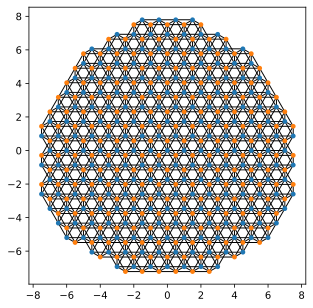

In [4]:
lat = kwant.lattice.honeycomb(norbs=1)
a, b = lat.sublattices
syst = make_system()
kwant.plot(syst, fig_size=(5,5));

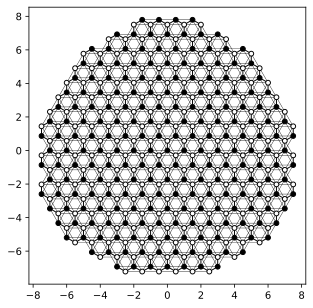

In [5]:
def family_color(site):
    return 'black' if site.family == a else 'white'

def hopping_lw(site1, site2):
    return 0.04 if site1.family == site2.family else 0.1

kwant.plot(syst, fig_size=(5,5), site_lw=0.1, site_color=family_color, hop_lw=hopping_lw);

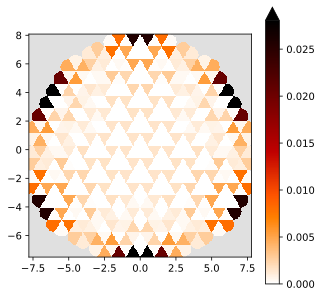

In [12]:
import scipy.linalg as la
syst = make_system(tp=0).finalized()
ham = syst.hamiltonian_submatrix()
evecs = la.eigh(ham)[1]
wf = abs(evecs[:, 225])**2
kwant.plotter.map(syst, wf, fig_size=(5,5), oversampling=10, cmap='gist_heat_r');

In [7]:
def family_shape(i):
    site = syst.sites[i]
    return ('p', 3, 180) if site.family == a else ('p', 3, 0)

def family_color(i):
    return 'black' if syst.sites[i].family == a else 'white'

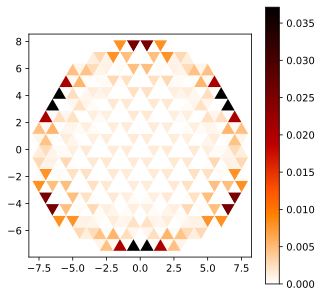

In [13]:
kwant.plot(syst, fig_size=(5,5), site_color=wf, site_symbol=family_shape, site_size=0.5, hop_lw=0, cmap='gist_heat_r');

In [9]:
def site_size(i):
    return 3 * wf[i] / wf.max()

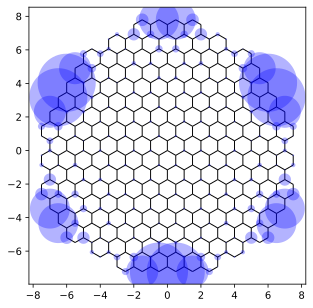

In [14]:
kwant.plot(syst, fig_size=(5,5), site_size=site_size, site_color=(0, 0, 1, 0.3),
           hop_lw=0.1);